In [ ]:
# Problem Statement:

# Heart disease is one of the leading causes of death worldwide.
# Early prediction of heart disease can help doctors take preventive
# measures and improve patient outcomes.
#
# The goal of this project is to build a Machine Learning model
# that can predict whether a person has heart disease or not
# based on various medical attributes such as age, cholesterol,
# blood pressure, heart rate, etc.

# Objectives:

# 1. Load and explore the heart disease dataset.
# 2. Understand the dataset structure using shape, info, and statistical summary.
# 3. Check for missing values and duplicate records to ensure data quality.
# 4. Perform Exploratory Data Analysis (EDA) using visualization techniques.
# 5. Identify relationships between features using correlation analysis.
# 6. Split the dataset into training and testing datasets.
# 7. Train a Machine Learning model (Logistic Regression) to predict heart disease.
# 8. Evaluate the model using accuracy score, classification report, and confusion matrix.
# 9. Test the model with new sample input data to verify predictions.
# 10.Save the trained model as a pickle file for future use.

# import libraries required
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [21]:
# Load dataset
df = pd.read_csv("heart_disease_data.csv")

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [22]:
print("Shape of dataset:", df.shape)

print("\nDataset Info:")
df.info()

print("\nStatistical Summary:")
df.describe()

Shape of dataset: (303, 14)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB

Statistical Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [23]:
# Check missing values
print("Missing Values:\n")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate Rows: 1


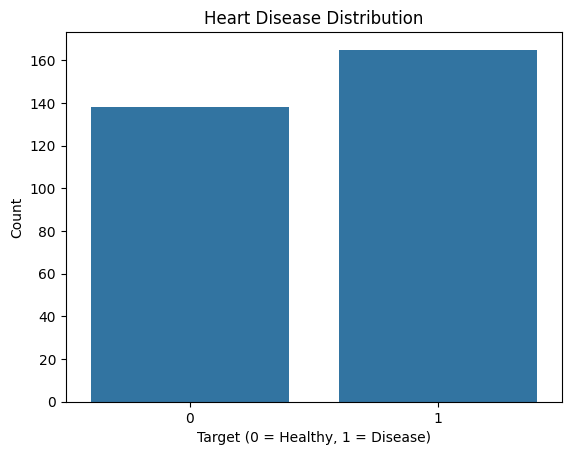

In [24]:
plt.figure()
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.xlabel("Target (0 = Healthy, 1 = Disease)")
plt.ylabel("Count")
plt.savefig("target_distribution.png")
plt.show()

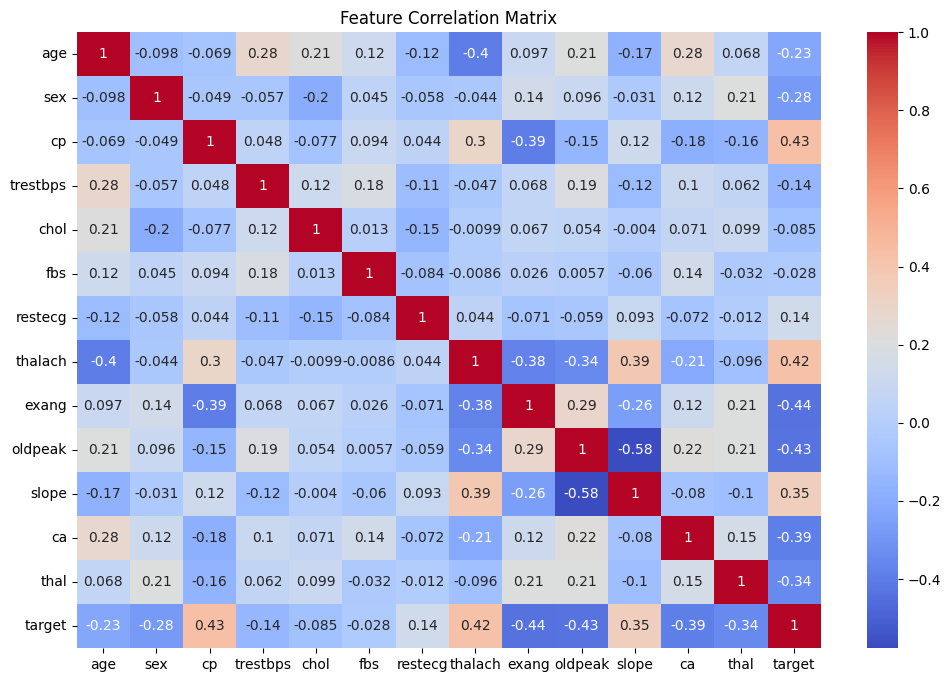

In [25]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.savefig("correlation_matrix.png")
plt.show()

In [26]:
X = df.drop(columns='target', axis=1)
Y = df['target']

print("Features shape:", X.shape)
print("Target shape:", Y.shape)

Features shape: (303, 13)
Target shape: (303,)


In [27]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, stratify=Y, random_state=2
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (242, 13)
Testing Data Shape: (61, 13)


In [28]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, Y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [29]:
X_test_prediction = model.predict(X_test)

accuracy = accuracy_score(Y_test, X_test_prediction)

print("Accuracy Score:", accuracy)

print("\nClassification Report:\n")
print(classification_report(Y_test, X_test_prediction))

Accuracy Score: 0.8032786885245902

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.79      0.79        28
           1       0.82      0.82      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



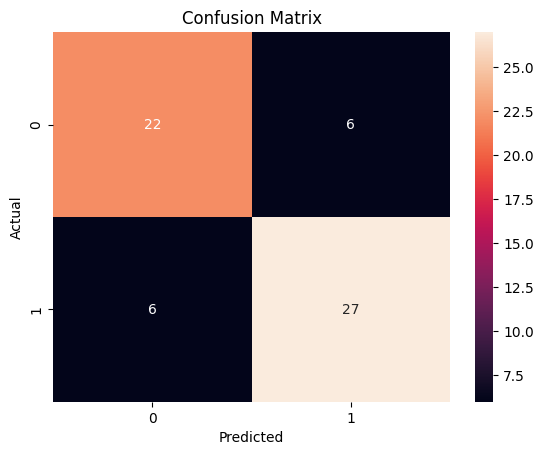

In [30]:
cm = confusion_matrix(Y_test, X_test_prediction)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix.png")
plt.show()

In [31]:
input_data = (63,1,3,145,233,1,0,150,0,2.3,0,0,1)

input_data_array = np.asarray(input_data)

input_data_reshaped = input_data_array.reshape(1,-1)

prediction = model.predict(input_data_reshaped)

print(prediction)

if prediction[0] == 0:
    print("The Person does not have Heart Disease")
else:
    print("The Person has Heart Disease")

[1]
The Person has Heart Disease


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


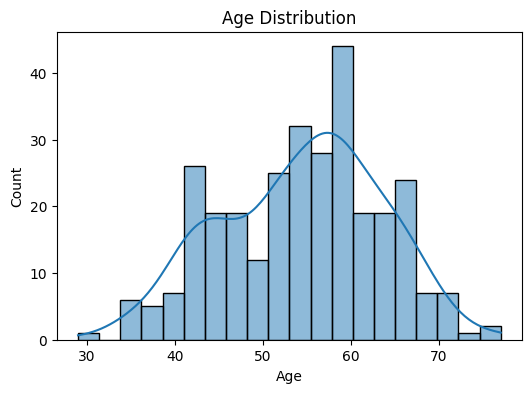

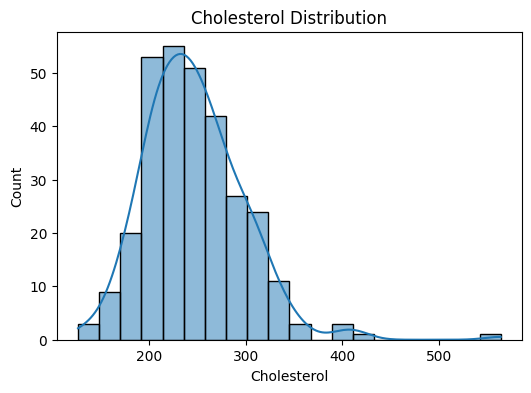

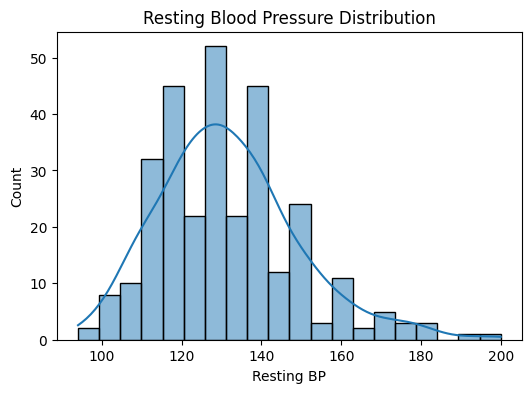

In [32]:
# Univariate Analysis

import matplotlib.pyplot as plt
import seaborn as sns

# Age distribution
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# Cholesterol distribution
plt.figure(figsize=(6,4))
sns.histplot(df['chol'], bins=20, kde=True)
plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Count")
plt.show()

# Resting Blood Pressure distribution
plt.figure(figsize=(6,4))
sns.histplot(df['trestbps'], bins=20, kde=True)
plt.title("Resting Blood Pressure Distribution")
plt.xlabel("Resting BP")
plt.ylabel("Count")
plt.show()

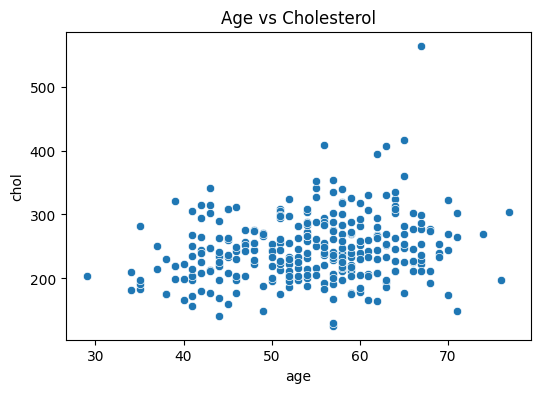

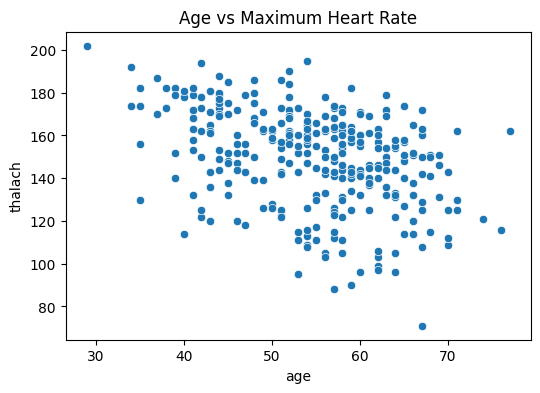

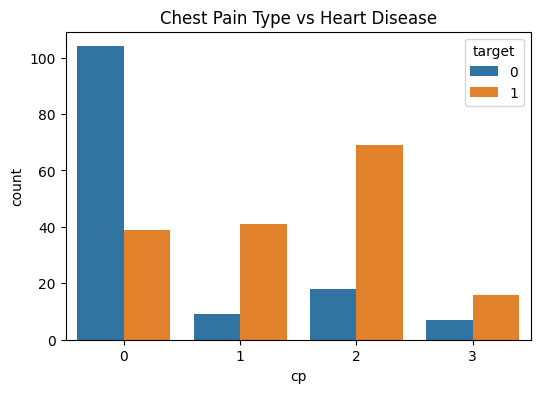

In [33]:
# Bivariate Analysis

# Age vs Cholesterol
plt.figure(figsize=(6,4))
sns.scatterplot(x='age', y='chol', data=df)
plt.title("Age vs Cholesterol")
plt.show()

# Age vs Max Heart Rate
plt.figure(figsize=(6,4))
sns.scatterplot(x='age', y='thalach', data=df)
plt.title("Age vs Maximum Heart Rate")
plt.show()

# Chest Pain Type vs Target
plt.figure(figsize=(6,4))
sns.countplot(x='cp', hue='target', data=df)
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

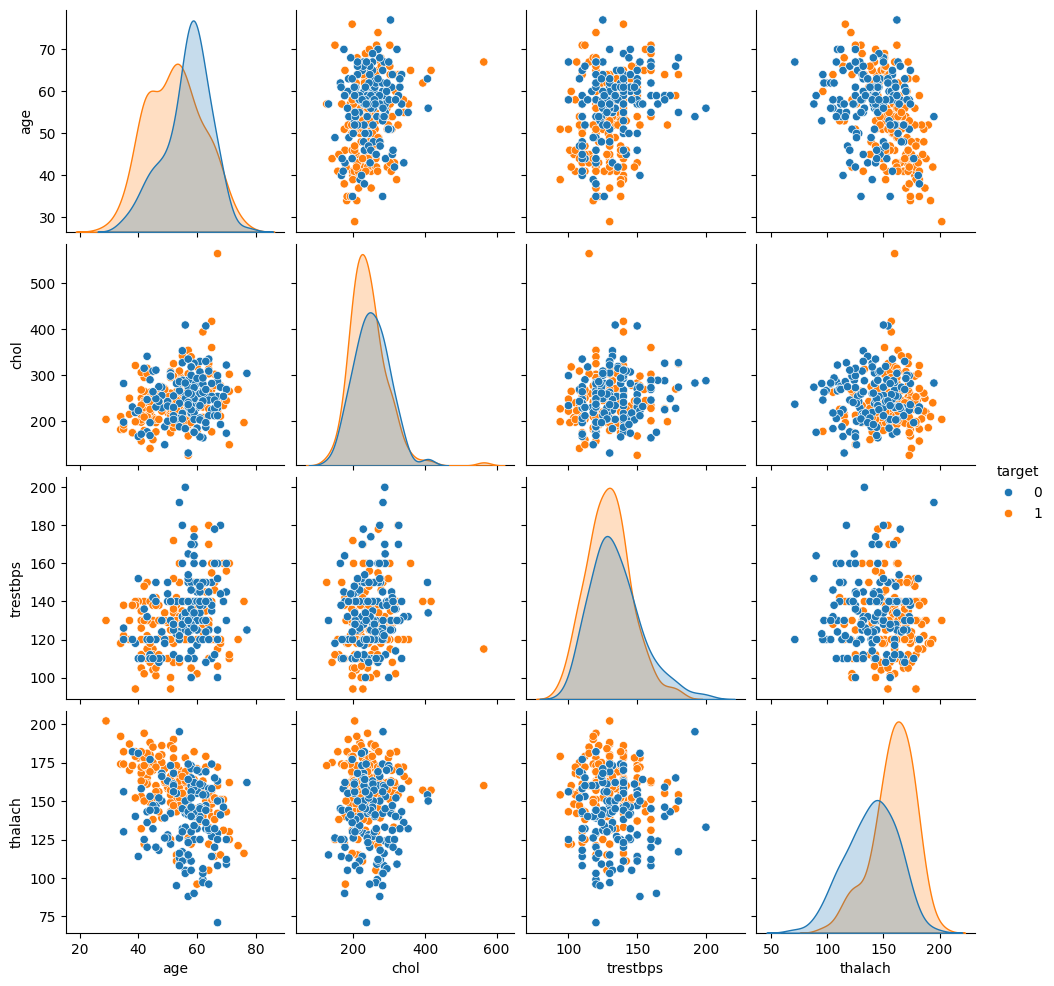

In [34]:
# Multivariate Analysis
# Pairplot for important features
features = ['age','chol','trestbps','thalach','target']
sns.pairplot(df[features], hue='target')
plt.show()

In [35]:
# saving the model
with open("heart_disease_model_2.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved as heart_disease_model_2.pkl")

Model saved as heart_disease_model_2.pkl


In [ ]:
# Insights from Plotted Graphs:

# Target Distribution Plot
# The count plot shows the distribution of patients with and without
# heart disease. The dataset appears relatively balanced, which helps
# in training a reliable machine learning model.

# Correlation Heatmap
# The heatmap shows relationships between different medical features.
# Some features show positive or negative correlation with the target
# variable, indicating that they contribute to predicting heart disease.

# Age Distribution (Univariate)
# The histogram indicates that most patients fall within the middle-age
# to older-age range, which aligns with known medical trends where
# heart disease risk increases with age.

# Cholesterol and Blood Pressure Distribution
# The distribution of cholesterol and resting blood pressure shows
# variability among patients, suggesting that these factors can play
# a role in cardiovascular health.

# Age vs Cholesterol (Bivariate)
# The scatter plot shows that cholesterol levels vary across age groups.
# Some older patients show higher cholesterol levels, which may increase
# heart disease risk.

# Age vs Maximum Heart Rate
# The relationship suggests that maximum heart rate tends to decrease
# with increasing age, which is a common physiological pattern.

# Chest Pain Type vs Target
# Certain chest pain categories appear more frequently in patients
# diagnosed with heart disease, making this an important predictive feature.

# Pairplot (Multivariate Analysis)
# The pairplot visualizes relationships between multiple features such as
# age, cholesterol, resting blood pressure, and maximum heart rate.
# It helps identify patterns and clusters related to the target variable.

# Model Performance Insights:

# The Logistic Regression model was successfully trained using the
# training dataset and evaluated on the testing dataset.

# The accuracy score indicates that the model performs reasonably well
# in predicting whether a patient has heart disease or not.

# The classification report provides precision, recall, and F1-score
# for both classes, helping evaluate model reliability.

# The confusion matrix visualization shows how many predictions were
# correct and where misclassifications occurred.

In [2]:
# Final Conclusion:

# In this notebook, a complete machine learning workflow was implemented
# for heart disease prediction.

# The dataset was explored and visualized using multiple techniques
# including univariate, bivariate, and multivariate analysis.

# Logistic Regression was used as the classification model to predict
# the presence of heart disease based on medical attributes.

# The trained model achieved a satisfactory accuracy score and was
# evaluated using multiple performance metrics.

# Finally, the trained model was saved as a pickle file so that it can
# be reused later in applications such as healthcare prediction systems
# or web-based diagnostic tools.

# This project demonstrates how machine learning can assist in
# identifying potential heart disease risks using patient data.
